# Análisis Zero-Shot de Clasificación de Pólipos

Este cuaderno analiza la salida del `batch_runner.py` para el experimento zero-shot.
Se evalúa la calidad de clasificación (`predicted_class`) frente al ground truth (`ground_truth_cls`)
y se revisan métricas de rendimiento del modelo (TTFT y TPS).

## 1) Configurar entorno y dependencias

Si faltan paquetes, ejecuta: `uv add scikit-learn seaborn`.

In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)

## 2) Definir parámetros y constantes iniciales

Ajusta estas rutas según tu ejecución más reciente.

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

BATCH_RESULTS_DIR = PROJECT_ROOT / "data" / "processed" / "batch_results"
batch_candidates = sorted(
    BATCH_RESULTS_DIR.glob("batch_*PolypClassification*.jsonl"),
    key=lambda p: p.stat().st_mtime,
    reverse=True,
)
if not batch_candidates:
    raise FileNotFoundError(f"No batch JSONL files found in: {BATCH_RESULTS_DIR}")

RESULTS_PATH = batch_candidates[0]

manifest_candidates = sorted(
    (PROJECT_ROOT / "data" / "experiments").glob("zeroshot_manifest*.jsonl"),
    key=lambda p: p.stat().st_mtime,
    reverse=True,
)
MANIFEST_PATH_HINT = manifest_candidates[0] if manifest_candidates else None

OUTPUT_DIR = PROJECT_ROOT / "data" / "processed" / "batch_results" / "analysis"
PLOTS_DIR = OUTPUT_DIR / "plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

VALID_CLASSES = ["AD", "HP", "ASS", "UNKNOWN"]
generated_plot_paths: list[Path] = []

print(f"Project root: {PROJECT_ROOT}")
print(f"Results path (latest): {RESULTS_PATH}")
print(f"Manifest hint: {MANIFEST_PATH_HINT if MANIFEST_PATH_HINT else 'N/A'}")
print(f"Plots dir: {PLOTS_DIR}")

Project root: c:\Users\david\Desktop\TFG\TFG_VLM_Medical
Results path (latest): c:\Users\david\Desktop\TFG\TFG_VLM_Medical\data\processed\batch_results\batch_zeroshot_manifest_20260316_140817_PolypClassification.jsonl
Manifest hint: c:\Users\david\Desktop\TFG\TFG_VLM_Medical\data\experiments\zeroshot_manifest_20260316_140817.jsonl
Plots dir: c:\Users\david\Desktop\TFG\TFG_VLM_Medical\data\processed\batch_results\analysis\plots


## 3) Implementar funciones base

Estas funciones encapsulan la carga robusta, parseo del `payload` y resolución de ground truth.

In [3]:
def load_table(path: Path) -> pd.DataFrame:
    """Load CSV or JSONL files into a DataFrame."""
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    suffix = path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix == ".jsonl":
        rows: list[dict[str, Any]] = []
        with path.open("r", encoding="utf-8") as f:
            for raw in f:
                line = raw.strip()
                if not line:
                    continue
                rows.append(json.loads(line))
        return pd.DataFrame(rows)

    raise ValueError(f"Unsupported file extension: {suffix}")


def split_batch_rows(df: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, Any] | None, dict[str, Any] | None]:
    """Separate execution rows from optional __batch_meta__/__batch_summary__ lines."""
    work = df.copy()

    meta: dict[str, Any] | None = None
    summary: dict[str, Any] | None = None

    if "__batch_meta__" in work.columns:
        meta_series = work["__batch_meta__"].dropna()
        if not meta_series.empty and isinstance(meta_series.iloc[0], dict):
            meta = meta_series.iloc[0]

    if "__batch_summary__" in work.columns:
        summary_series = work["__batch_summary__"].dropna()
        if not summary_series.empty and isinstance(summary_series.iloc[0], dict):
            summary = summary_series.iloc[-1]

    meta_mask = work.get("__batch_meta__", pd.Series([np.nan] * len(work))).notna()
    summary_mask = work.get("__batch_summary__", pd.Series([np.nan] * len(work))).notna()
    exec_df = work.loc[~(meta_mask | summary_mask)].copy()

    return exec_df, meta, summary


def resolve_manifest_path(batch_meta: dict[str, Any] | None, manifest_hint: Path | None) -> Path | None:
    """Resolve manifest path from batch meta first; fallback to explicit hint."""
    if batch_meta:
        candidates = batch_meta.get("manifest_paths") or []
        for raw in candidates:
            candidate = Path(str(raw))
            if candidate.exists():
                return candidate

    if manifest_hint and manifest_hint.exists():
        return manifest_hint
    return None


def parse_payload(value: Any) -> dict[str, Any]:
    """Parse payload if it is already a dict or a JSON string."""
    if isinstance(value, dict):
        return value
    if isinstance(value, str):
        text = value.strip()
        if not text:
            return {}
        try:
            parsed = json.loads(text)
            return parsed if isinstance(parsed, dict) else {}
        except json.JSONDecodeError:
            return {}
    return {}


def as_bool(value: Any) -> bool:
    """Best-effort conversion for include_reasoning values."""
    if isinstance(value, bool):
        return value
    if pd.isna(value):
        return False
    return str(value).strip().lower() in {"1", "true", "yes", "y", "si"}


def to_safe_slug(value: Any) -> str:
    """Convert arbitrary labels into filesystem-safe slug tokens."""
    text = str(value or "").strip()
    if not text:
        return "na"
    slug = "".join(ch if ch.isalnum() or ch in "-_" else "_" for ch in text)
    return slug.strip("_") or "na"


def resolve_ground_truth(results_df: pd.DataFrame, manifest_df: pd.DataFrame | None = None) -> pd.DataFrame:
    """Prefer in-row ground truth and fallback to manifest merge by image_id or image_path."""
    df = results_df.copy()
    if "ground_truth_cls" not in df.columns:
        df["ground_truth_cls"] = np.nan

    needs_fallback = df["ground_truth_cls"].isna() | (df["ground_truth_cls"].astype(str).str.strip() == "")

    if manifest_df is None or manifest_df.empty or not needs_fallback.any():
        return df

    manifest = manifest_df.copy()
    for col in ["image_id", "image_path", "ground_truth_cls"]:
        if col not in manifest.columns:
            manifest[col] = np.nan

    fallback_cols = ["image_id", "image_path"]
    fallback_map = manifest[fallback_cols + ["ground_truth_cls"]].dropna(subset=["ground_truth_cls"])

    by_id = (
        fallback_map.dropna(subset=["image_id"])
        .drop_duplicates(subset=["image_id"])
        .set_index("image_id")["ground_truth_cls"]
    )
    by_path = (
        fallback_map.dropna(subset=["image_path"])
        .drop_duplicates(subset=["image_path"])
        .set_index("image_path")["ground_truth_cls"]
    )

    missing_idx = df.index[needs_fallback]
    for idx in missing_idx:
        image_id = df.at[idx, "image_id"] if "image_id" in df.columns else np.nan
        image_path = df.at[idx, "image_path"] if "image_path" in df.columns else np.nan

        if pd.notna(image_id) and image_id in by_id.index:
            df.at[idx, "ground_truth_cls"] = by_id.loc[image_id]
        elif pd.notna(image_path) and image_path in by_path.index:
            df.at[idx, "ground_truth_cls"] = by_path.loc[image_path]

    return df

## 4) Construir el flujo principal de ejecución

Se carga la salida del batch, se extrae `predicted_class` y se alinea con el ground truth.

In [4]:
raw_df = load_table(RESULTS_PATH)
results_df, batch_meta, batch_summary = split_batch_rows(raw_df)

manifest_path = resolve_manifest_path(batch_meta, MANIFEST_PATH_HINT)
manifest_df = load_table(manifest_path) if manifest_path and manifest_path.exists() else None

if "payload" in results_df.columns:
    results_df["payload_parsed"] = results_df["payload"].apply(parse_payload)
else:
    results_df["payload_parsed"] = [{} for _ in range(len(results_df))]

results_df["predicted_class"] = results_df["payload_parsed"].apply(lambda d: d.get("predicted_class"))

if "include_reasoning" not in results_df.columns:
    results_df["include_reasoning"] = False
results_df["include_reasoning"] = results_df["include_reasoning"].apply(as_bool)
results_df["variant"] = np.where(results_df["include_reasoning"], "with_reasoning", "no_reasoning")

eval_df = resolve_ground_truth(results_df, manifest_df=manifest_df)

if "status" in eval_df.columns:
    eval_df = eval_df[eval_df["status"] == "ok"].copy()

eval_df["predicted_class"] = eval_df["predicted_class"].astype(str).str.upper()
eval_df["ground_truth_cls"] = eval_df["ground_truth_cls"].astype(str).str.upper()
eval_df = eval_df[
    eval_df["predicted_class"].isin(VALID_CLASSES)
    & eval_df["ground_truth_cls"].isin(VALID_CLASSES)
].copy()

variant_counts_df = pd.DataFrame()
combo_counts_df = pd.DataFrame()
if "variant" in eval_df.columns:
    variant_counts_df = (
        eval_df.groupby(["variant"], dropna=False)
        .size()
        .rename("n_rows")
        .reset_index()
        .sort_values(["n_rows", "variant"], ascending=[False, True])
        .reset_index(drop=True)
    )
if {"model_id", "variant"}.issubset(eval_df.columns):
    combo_counts_df = (
        eval_df.groupby(["model_id", "variant"], dropna=False)
        .size()
        .rename("n_rows")
        .reset_index()
        .sort_values(["n_rows", "model_id", "variant"], ascending=[False, True, True])
        .reset_index(drop=True)
    )

print(f"Rows in raw file: {len(raw_df)}")
print(f"Rows for execution (without meta/summary): {len(results_df)}")
print(f"Rows used for evaluation: {len(eval_df)}")
print(f"Manifest used: {manifest_path if manifest_path else 'N/A'}")
if batch_meta is not None:
    print(f"Meta schemas: {batch_meta.get('schema_names')}")
if batch_summary is not None:
    print("Summary row detected in JSONL.")
else:
    print("No __batch_summary__ row found in JSONL.")

if not variant_counts_df.empty:
    print("\nRows por variante:")
    display(variant_counts_df)

if not combo_counts_df.empty:
    print("\nRows por model_id + variante:")
    display(combo_counts_df)

preview_cols = [
    col
    for col in ["model_id", "variant", "image_id", "image_path", "ground_truth_cls", "predicted_class"]
    if col in eval_df.columns
]
eval_df[preview_cols].head(10)

Rows in raw file: 1802
Rows for execution (without meta/summary): 1800
Rows used for evaluation: 1800
Manifest used: C:\Users\david\Desktop\TFG\TFG_VLM_Medical\data\experiments\zeroshot_manifest_20260316_140817.jsonl
Meta schemas: ['PolypClassification']
Summary row detected in JSONL.

Rows por variante:


,variant,n_rows
0,no_reasoning,900
1,with_reasoning,900



Rows por model_id + variante:


,model_id,variant,n_rows
0,minicpm-v-4_5@q8_0,no_reasoning,300
1,minicpm-v-4_5@q8_0,with_reasoning,300
2,opengvlab_internvl3_5-8b@q8_0,no_reasoning,300
3,opengvlab_internvl3_5-8b@q8_0,with_reasoning,300
4,qwen3_5-9b@q8_0,no_reasoning,300
5,qwen3_5-9b@q8_0,with_reasoning,300


,model_id,variant,image_id,image_path,ground_truth_cls,predicted_class
1,opengvlab_internvl3_5-8b@q8_0,no_reasoning,310,C:\Users\david\Desktop\TFG\TFG_VLM_Medical\dat...,HP,HP
2,opengvlab_internvl3_5-8b@q8_0,no_reasoning,310,C:\Users\david\Desktop\TFG\TFG_VLM_Medical\dat...,HP,HP
3,opengvlab_internvl3_5-8b@q8_0,no_reasoning,310,C:\Users\david\Desktop\TFG\TFG_VLM_Medical\dat...,HP,HP
4,opengvlab_internvl3_5-8b@q8_0,no_reasoning,587,C:\Users\david\Desktop\TFG\TFG_VLM_Medical\dat...,AD,AD
5,opengvlab_internvl3_5-8b@q8_0,no_reasoning,587,C:\Users\david\Desktop\TFG\TFG_VLM_Medical\dat...,AD,AD
6,opengvlab_internvl3_5-8b@q8_0,no_reasoning,587,C:\Users\david\Desktop\TFG\TFG_VLM_Medical\dat...,AD,HP
7,opengvlab_internvl3_5-8b@q8_0,no_reasoning,630,C:\Users\david\Desktop\TFG\TFG_VLM_Medical\dat...,ASS,AD
8,opengvlab_internvl3_5-8b@q8_0,no_reasoning,630,C:\Users\david\Desktop\TFG\TFG_VLM_Medical\dat...,ASS,AD
9,opengvlab_internvl3_5-8b@q8_0,no_reasoning,630,C:\Users\david\Desktop\TFG\TFG_VLM_Medical\dat...,ASS,AD
10,opengvlab_internvl3_5-8b@q8_0,no_reasoning,452,C:\Users\david\Desktop\TFG\TFG_VLM_Medical\dat...,AD,AD


## 5) Agregar validaciones y pruebas rápidas

Se comprueba consistencia mínima antes de calcular métricas.

In [5]:
assert len(eval_df) > 0, "No hay filas válidas para evaluación. Revisa filtros, status o rutas."
assert eval_df["predicted_class"].isin(VALID_CLASSES).all(), "Hay clases predichas fuera del conjunto esperado."
assert eval_df["ground_truth_cls"].isin(VALID_CLASSES).all(), "Hay etiquetas GT fuera del conjunto esperado."


def compute_metric_rows(df_slice: pd.DataFrame, group_name: str) -> list[dict[str, Any]]:
    y_true_local = df_slice["ground_truth_cls"]
    y_pred_local = df_slice["predicted_class"]

    accuracy = accuracy_score(y_true_local, y_pred_local)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true_local, y_pred_local, labels=VALID_CLASSES, average="macro", zero_division=0
    )
    precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(
        y_true_local, y_pred_local, labels=VALID_CLASSES, average="micro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true_local, y_pred_local, labels=VALID_CLASSES, average="weighted", zero_division=0
    )

    return [
        {"group": group_name, "metric": "accuracy", "value": accuracy, "n": len(df_slice)},
        {"group": group_name, "metric": "precision_macro", "value": precision_macro, "n": len(df_slice)},
        {"group": group_name, "metric": "recall_macro", "value": recall_macro, "n": len(df_slice)},
        {"group": group_name, "metric": "f1_macro", "value": f1_macro, "n": len(df_slice)},
        {"group": group_name, "metric": "precision_micro", "value": precision_micro, "n": len(df_slice)},
        {"group": group_name, "metric": "recall_micro", "value": recall_micro, "n": len(df_slice)},
        {"group": group_name, "metric": "f1_micro", "value": f1_micro, "n": len(df_slice)},
        {"group": group_name, "metric": "precision_weighted", "value": precision_weighted, "n": len(df_slice)},
        {"group": group_name, "metric": "recall_weighted", "value": recall_weighted, "n": len(df_slice)},
        {"group": group_name, "metric": "f1_weighted", "value": f1_weighted, "n": len(df_slice)},
    ]


metrics_rows: list[dict[str, Any]] = []
metrics_rows.extend(compute_metric_rows(eval_df, "overall"))

if {"model_id", "variant"}.issubset(eval_df.columns):
    for (model_id, variant), group_df in eval_df.groupby(["model_id", "variant"], dropna=False):
        metrics_rows.extend(compute_metric_rows(group_df, f"{model_id} | {variant}"))

metrics_df = pd.DataFrame(metrics_rows)


y_true = eval_df["ground_truth_cls"]
y_pred = eval_df["predicted_class"]
report_dict = classification_report(
    y_true, y_pred, labels=VALID_CLASSES, output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report_dict).T

if {"model_id", "variant"}.issubset(eval_df.columns):
    report_by_group_rows: list[dict[str, Any]] = []
    for (model_id, variant), group_df in eval_df.groupby(["model_id", "variant"], dropna=False):
        local_report = classification_report(
            group_df["ground_truth_cls"],
            group_df["predicted_class"],
            labels=VALID_CLASSES,
            output_dict=True,
            zero_division=0,
        )
        for label, values in local_report.items():
            if isinstance(values, dict):
                report_by_group_rows.append(
                    {
                        "model_id": model_id,
                        "variant": variant,
                        "label": label,
                        **values,
                    }
                )
    report_by_group_df = pd.DataFrame(report_by_group_rows)
else:
    report_by_group_df = pd.DataFrame()

display(metrics_df.sort_values(["group", "metric"]).reset_index(drop=True))
display(report_df)
if not report_by_group_df.empty:
    display(report_by_group_df.head(20))

,group,metric,value,n
0,minicpm-v-4_5@q8_0 | no_reasoning,accuracy,0.473333,300
1,minicpm-v-4_5@q8_0 | no_reasoning,f1_macro,0.244939,300
2,minicpm-v-4_5@q8_0 | no_reasoning,f1_micro,0.473333,300
3,minicpm-v-4_5@q8_0 | no_reasoning,f1_weighted,0.473787,300
4,minicpm-v-4_5@q8_0 | no_reasoning,precision_macro,0.254180,300
...,...,...,...,...
65,qwen3_5-9b@q8_0 | with_reasoning,precision_micro,0.683333,300
66,qwen3_5-9b@q8_0 | with_reasoning,precision_weighted,0.679204,300
67,qwen3_5-9b@q8_0 | with_reasoning,recall_macro,0.373262,300
68,qwen3_5-9b@q8_0 | with_reasoning,recall_micro,0.683333,300


,precision,recall,f1-score,support
AD,0.760634,0.756219,0.758420,1206.000000
HP,0.320072,0.578431,0.412107,306.000000
ASS,0.250000,0.041667,0.071429,288.000000
UNKNOWN,0.000000,0.000000,0.000000,0.000000
accuracy,0.611667,0.611667,0.611667,0.611667
macro avg,0.332677,0.344079,0.310489,1800.000000
weighted avg,0.604037,0.611667,0.589628,1800.000000


,model_id,variant,label,precision,recall,f1-score,support
0,minicpm-v-4_5@q8_0,no_reasoning,AD,0.778626,0.507463,0.614458,201.0
1,minicpm-v-4_5@q8_0,no_reasoning,HP,0.238095,0.784314,0.365297,51.0
2,minicpm-v-4_5@q8_0,no_reasoning,ASS,0.000000,0.000000,0.000000,48.0
3,minicpm-v-4_5@q8_0,no_reasoning,UNKNOWN,0.000000,0.000000,0.000000,0.0
4,minicpm-v-4_5@q8_0,no_reasoning,macro avg,0.254180,0.322944,0.244939,300.0
5,minicpm-v-4_5@q8_0,no_reasoning,weighted avg,0.562156,0.473333,0.473787,300.0
6,minicpm-v-4_5@q8_0,with_reasoning,AD,0.754286,0.656716,0.702128,201.0
7,minicpm-v-4_5@q8_0,with_reasoning,HP,0.262295,0.627451,0.369942,51.0
8,minicpm-v-4_5@q8_0,with_reasoning,ASS,0.000000,0.000000,0.000000,48.0
9,minicpm-v-4_5@q8_0,with_reasoning,UNKNOWN,0.000000,0.000000,0.000000,0.0


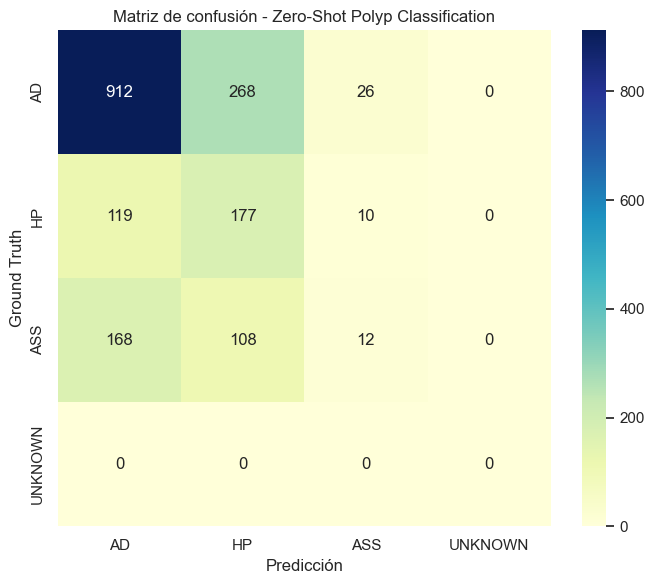

Saved: c:\Users\david\Desktop\TFG\TFG_VLM_Medical\data\processed\batch_results\analysis\plots\cm_overall.png


In [6]:
cm = confusion_matrix(y_true, y_pred, labels=VALID_CLASSES)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    xticklabels=VALID_CLASSES,
    yticklabels=VALID_CLASSES,
    cbar=True,
)
plt.title("Matriz de confusión - Zero-Shot Polyp Classification")
plt.xlabel("Predicción")
plt.ylabel("Ground Truth")
plt.tight_layout()

overall_cm_plot_path = PLOTS_DIR / "cm_overall.png"
plt.savefig(overall_cm_plot_path, dpi=140, bbox_inches="tight")
if overall_cm_plot_path not in generated_plot_paths:
    generated_plot_paths.append(overall_cm_plot_path)
plt.show()

print(f"Saved: {overall_cm_plot_path}")

### 5.1) Comparación de Matriz de Confusión por Variante

Si el JSONL contiene más de una variante (`with_reasoning` y `no_reasoning`), se muestra una matriz por variante.

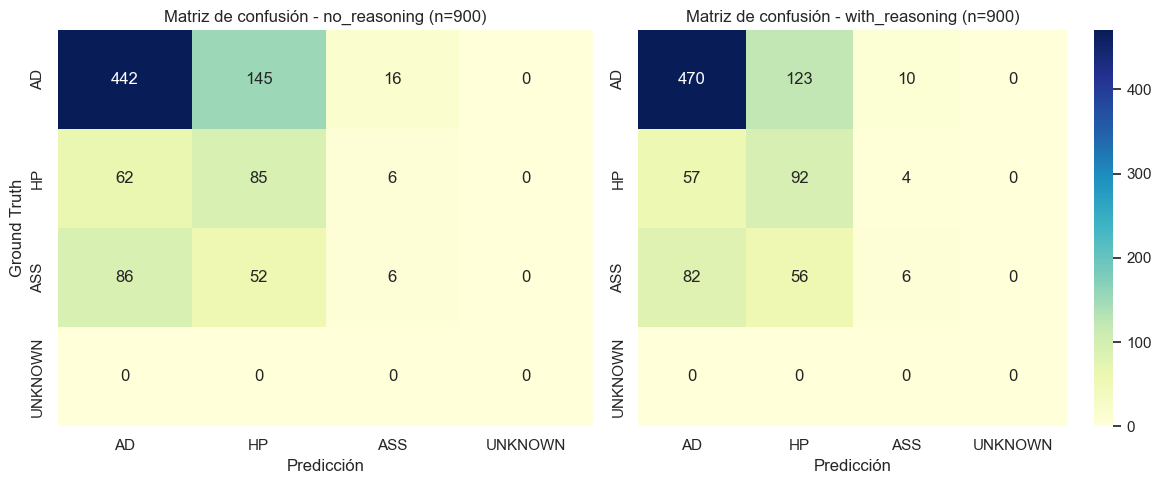

Saved: c:\Users\david\Desktop\TFG\TFG_VLM_Medical\data\processed\batch_results\analysis\plots\cm_by_variant.png
Saved individual variant plots in: c:\Users\david\Desktop\TFG\TFG_VLM_Medical\data\processed\batch_results\analysis\plots


In [7]:
if "variant" not in eval_df.columns:
    print("No existe la columna 'variant' en eval_df; no se puede comparar por variante.")
else:
    variant_values = [v for v in sorted(eval_df["variant"].dropna().unique()) if str(v).strip()]
    if len(variant_values) <= 1:
        print(
            "Solo hay una variante disponible en este JSONL "
            f"({variant_values[0] if variant_values else 'N/A'}); no hay comparación por variante."
        )
    else:
        n_variants = len(variant_values)
        fig, axes = plt.subplots(1, n_variants, figsize=(6 * n_variants, 5), squeeze=False)

        for idx, variant_name in enumerate(variant_values):
            ax = axes[0, idx]
            variant_df = eval_df[eval_df["variant"] == variant_name].copy()
            variant_cm = confusion_matrix(
                variant_df["ground_truth_cls"],
                variant_df["predicted_class"],
                labels=VALID_CLASSES,
            )
            sns.heatmap(
                variant_cm,
                annot=True,
                fmt="d",
                cmap="YlGnBu",
                xticklabels=VALID_CLASSES,
                yticklabels=VALID_CLASSES,
                cbar=(idx == n_variants - 1),
                ax=ax,
            )
            ax.set_title(f"Matriz de confusión - {variant_name} (n={len(variant_df)})")
            ax.set_xlabel("Predicción")
            if idx == 0:
                ax.set_ylabel("Ground Truth")
            else:
                ax.set_ylabel("")

            single_variant_plot_path = PLOTS_DIR / f"cm_variant_{to_safe_slug(variant_name)}.png"
            fig_single, ax_single = plt.subplots(1, 1, figsize=(6, 5))
            sns.heatmap(
                variant_cm,
                annot=True,
                fmt="d",
                cmap="YlGnBu",
                xticklabels=VALID_CLASSES,
                yticklabels=VALID_CLASSES,
                cbar=True,
                ax=ax_single,
            )
            ax_single.set_title(f"Matriz de confusión - {variant_name} (n={len(variant_df)})")
            ax_single.set_xlabel("Predicción")
            ax_single.set_ylabel("Ground Truth")
            fig_single.tight_layout()
            fig_single.savefig(single_variant_plot_path, dpi=140, bbox_inches="tight")
            if single_variant_plot_path not in generated_plot_paths:
                generated_plot_paths.append(single_variant_plot_path)
            plt.close(fig_single)

        plt.tight_layout()
        by_variant_plot_path = PLOTS_DIR / "cm_by_variant.png"
        plt.savefig(by_variant_plot_path, dpi=140, bbox_inches="tight")
        if by_variant_plot_path not in generated_plot_paths:
            generated_plot_paths.append(by_variant_plot_path)
        plt.show()
        print(f"Saved: {by_variant_plot_path}")
        print(f"Saved individual variant plots in: {PLOTS_DIR}")

### 5.2) Comparación de Matriz de Confusión por Modelo y Variante

Cuando el mismo JSONL contiene múltiples combinaciones `model_id | variant`, se genera una matriz de confusión por cada combinación.

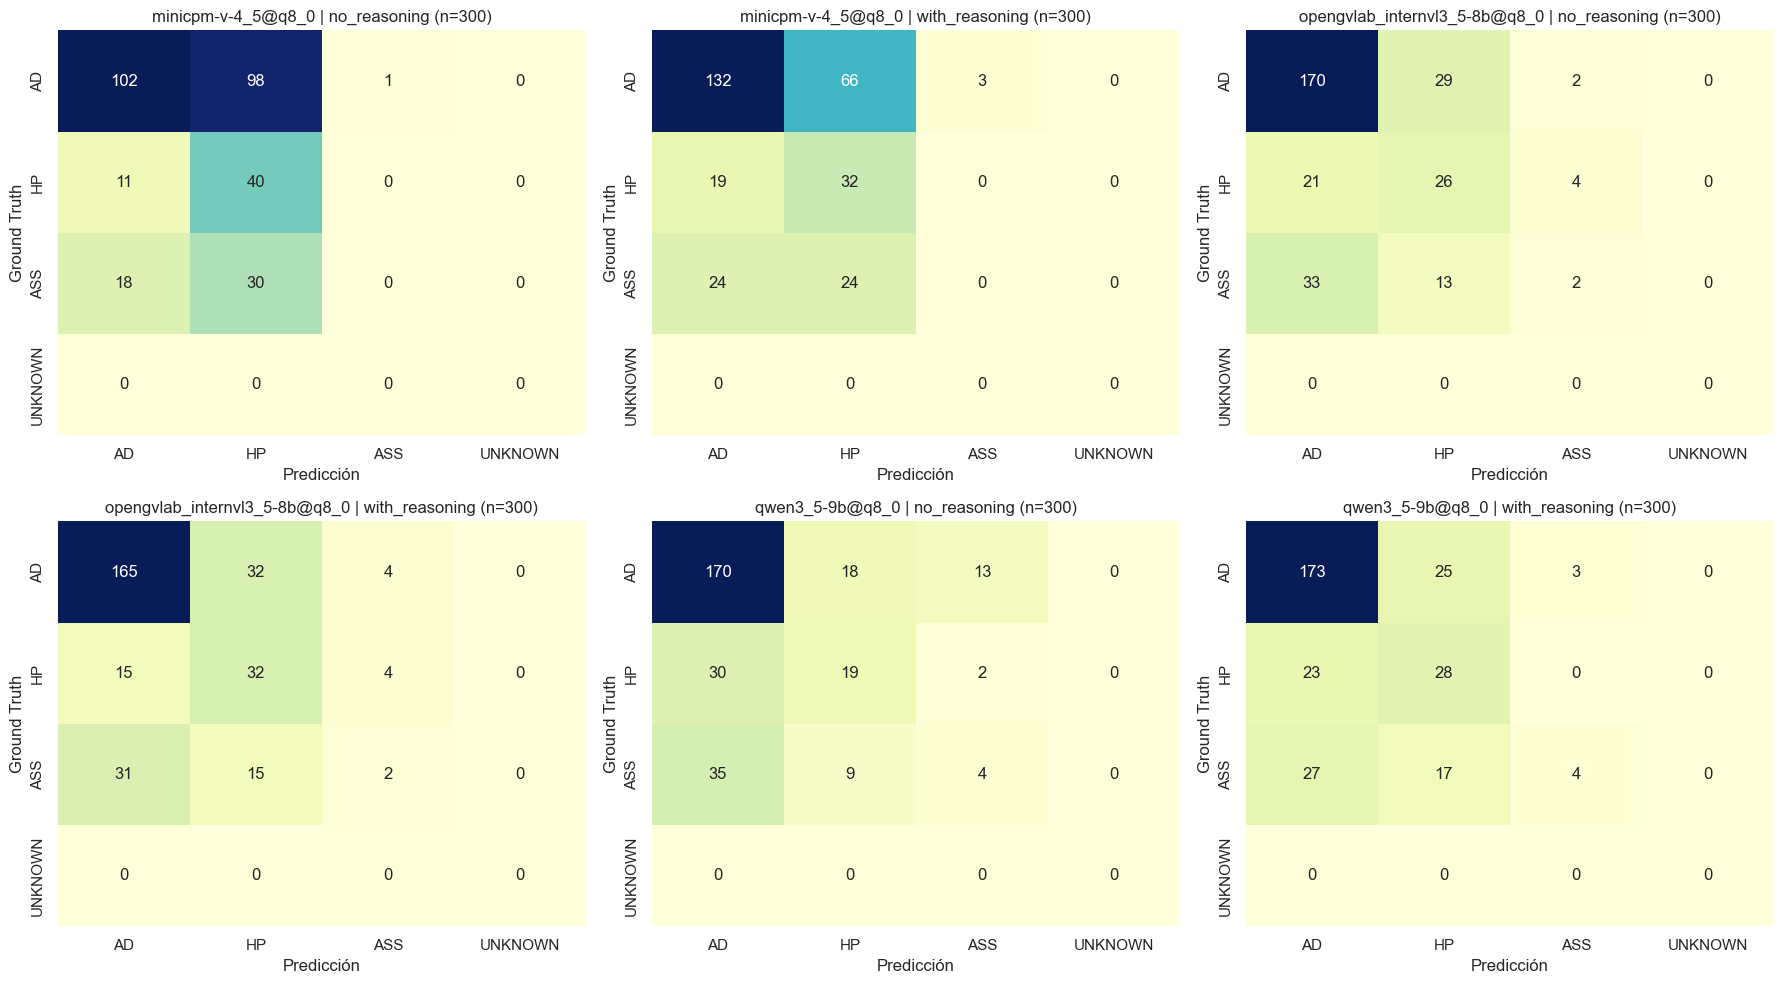

Saved: c:\Users\david\Desktop\TFG\TFG_VLM_Medical\data\processed\batch_results\analysis\plots\cm_by_model_variant.png
Saved individual plots in: c:\Users\david\Desktop\TFG\TFG_VLM_Medical\data\processed\batch_results\analysis\plots


In [8]:
if not {"model_id", "variant"}.issubset(eval_df.columns):
    print("Faltan columnas 'model_id' o 'variant'; no se puede comparar por modelo y variante.")
else:
    combo_df = (
        eval_df.groupby(["model_id", "variant"], dropna=False)
        .size()
        .rename("n")
        .reset_index()
        .sort_values(["n", "model_id", "variant"], ascending=[False, True, True])
    )

    combos = [
        (str(row.model_id), str(row.variant), int(row.n))
        for row in combo_df.itertuples(index=False)
        if str(row.model_id).strip() and str(row.variant).strip()
    ]

    if len(combos) <= 1:
        only_value = f"{combos[0][0]} | {combos[0][1]}" if combos else "N/A"
        print(
            "Solo hay una combinación model_id | variant disponible "
            f"({only_value}); no hay comparación cruzada."
        )
    else:
        n_panels = len(combos)
        n_cols = min(3, n_panels)
        n_rows = int(np.ceil(n_panels / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows), squeeze=False)

        for idx, (model_name, variant_name, n_rows_group) in enumerate(combos):
            row_idx, col_idx = divmod(idx, n_cols)
            ax = axes[row_idx, col_idx]
            subset_df = eval_df[
                (eval_df["model_id"] == model_name) & (eval_df["variant"] == variant_name)
            ].copy()
            subset_cm = confusion_matrix(
                subset_df["ground_truth_cls"],
                subset_df["predicted_class"],
                labels=VALID_CLASSES,
            )
            sns.heatmap(
                subset_cm,
                annot=True,
                fmt="d",
                cmap="YlGnBu",
                xticklabels=VALID_CLASSES,
                yticklabels=VALID_CLASSES,
                cbar=False,
                ax=ax,
            )
            ax.set_title(f"{model_name} | {variant_name} (n={n_rows_group})")
            ax.set_xlabel("Predicción")
            ax.set_ylabel("Ground Truth")

            safe_model = "".join(ch if ch.isalnum() or ch in "-_" else "_" for ch in model_name)
            safe_variant = "".join(ch if ch.isalnum() or ch in "-_" else "_" for ch in variant_name)
            single_plot_path = PLOTS_DIR / f"cm_{safe_model}_{safe_variant}.png"
            fig_single, ax_single = plt.subplots(1, 1, figsize=(6, 5))
            sns.heatmap(
                subset_cm,
                annot=True,
                fmt="d",
                cmap="YlGnBu",
                xticklabels=VALID_CLASSES,
                yticklabels=VALID_CLASSES,
                cbar=True,
                ax=ax_single,
            )
            ax_single.set_title(f"{model_name} | {variant_name} (n={n_rows_group})")
            ax_single.set_xlabel("Predicción")
            ax_single.set_ylabel("Ground Truth")
            fig_single.tight_layout()
            fig_single.savefig(single_plot_path, dpi=140, bbox_inches="tight")
            plt.close(fig_single)

        for idx in range(n_panels, n_rows * n_cols):
            row_idx, col_idx = divmod(idx, n_cols)
            axes[row_idx, col_idx].axis("off")

        plt.tight_layout()
        by_combo_plot_path = PLOTS_DIR / "cm_by_model_variant.png"
        plt.savefig(by_combo_plot_path, dpi=140, bbox_inches="tight")
        plt.show()
        print(f"Saved: {by_combo_plot_path}")
        print(f"Saved individual plots in: {PLOTS_DIR}")

### 5.3) Distribuciones y Rendimiento por Clase

Se visualizan las distribuciones de `ttft_seconds` y `tokens_per_second`, y su comportamiento por clase predicha.

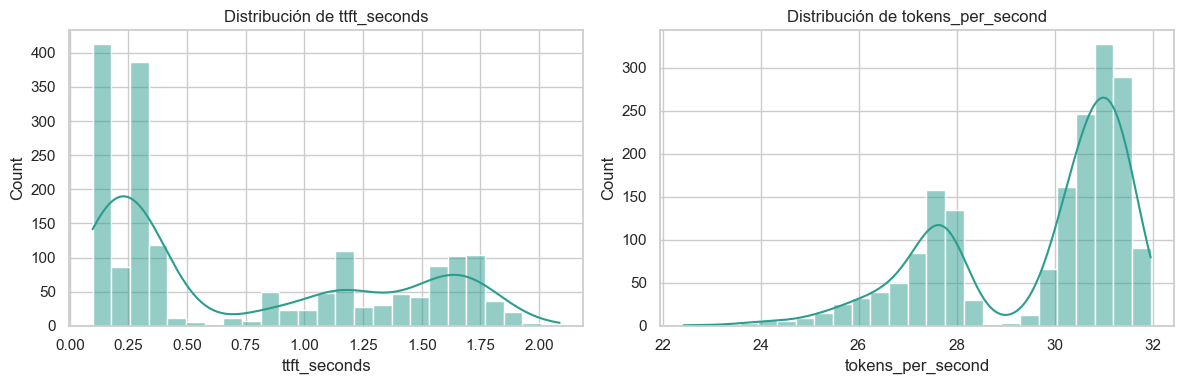

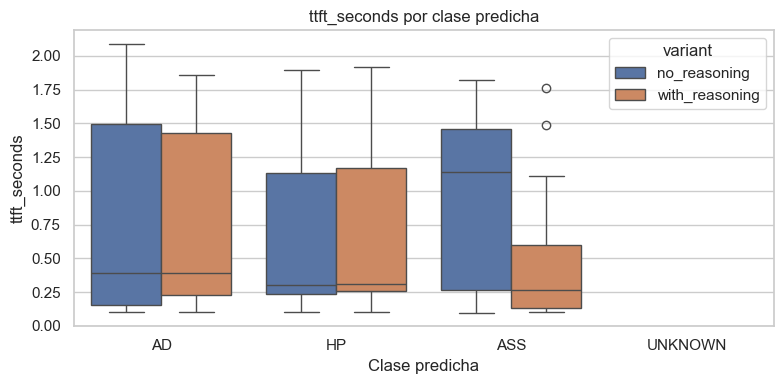

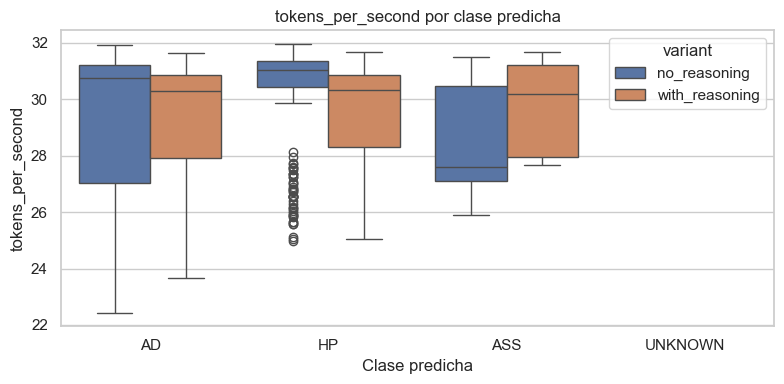

model_id         variant ttft_seconds                  \
                                                         mean  median     std   
0             minicpm-v-4_5@q8_0    no_reasoning       0.6123  0.3805  0.4674   
1             minicpm-v-4_5@q8_0  with_reasoning       0.6222  0.3800  0.4753   
2  opengvlab_internvl3_5-8b@q8_0    no_reasoning       0.1758  0.1400  0.0645   
3  opengvlab_internvl3_5-8b@q8_0  with_reasoning       0.1800  0.1420  0.0668   
4                qwen3_5-9b@q8_0    no_reasoning       1.4506  1.5580  0.3494   
5                qwen3_5-9b@q8_0  with_reasoning       1.3949  1.4790  0.3403   

  tokens_per_second                   
               mean   median     std  
0           31.0536  31.0901  0.4641  
1           30.3465  30.3818  0.4080  
2           31.1501  31.1677  0.3712  
3           30.9873  31.0814  0.4558  
4           26.5217  26.7668  1.0173  
5           27.7040  27.7860  0.4761

In [9]:
perf_cols = ["ttft_seconds", "tokens_per_second"]
available_perf = [col for col in perf_cols if col in eval_df.columns]

if available_perf:
    fig, axes = plt.subplots(1, len(available_perf), figsize=(6 * len(available_perf), 4))
    if len(available_perf) == 1:
        axes = [axes]

    for ax, col in zip(axes, available_perf):
        sns.histplot(eval_df[col].dropna(), kde=True, bins=25, ax=ax, color="#2a9d8f")
        ax.set_title(f"Distribución de {col}")
        ax.set_xlabel(col)

    plt.tight_layout()
    perf_hist_plot_path = PLOTS_DIR / "perf_histograms.png"
    plt.savefig(perf_hist_plot_path, dpi=140, bbox_inches="tight")
    if perf_hist_plot_path not in generated_plot_paths:
        generated_plot_paths.append(perf_hist_plot_path)
    plt.show()

    if "predicted_class" in eval_df.columns:
        for col in available_perf:
            plt.figure(figsize=(8, 4))
            hue_col = "variant" if "variant" in eval_df.columns else None
            sns.boxplot(
                data=eval_df,
                x="predicted_class",
                y=col,
                order=VALID_CLASSES,
                hue=hue_col,
            )
            plt.title(f"{col} por clase predicha")
            plt.xlabel("Clase predicha")
            plt.ylabel(col)
            plt.tight_layout()
            boxplot_path = PLOTS_DIR / f"perf_boxplot_{to_safe_slug(col)}.png"
            plt.savefig(boxplot_path, dpi=140, bbox_inches="tight")
            if boxplot_path not in generated_plot_paths:
                generated_plot_paths.append(boxplot_path)
            plt.show()

    if {"model_id", "variant"}.issubset(eval_df.columns):
        perf_summary_df = (
            eval_df.groupby(["model_id", "variant"])[available_perf]
            .agg(["mean", "median", "std"])
            .round(4)
            .reset_index()
        )
        display(perf_summary_df)
else:
    print("No se encontraron columnas TTFT/TPS en los resultados.")

## 6) Registrar salida y guardar resultados

Se guardan métricas agregadas y reporte por clase para trazabilidad del experimento.

In [10]:
metrics_output_path = OUTPUT_DIR / "zeroshot_metrics_summary.jsonl"
report_output_path = OUTPUT_DIR / "zeroshot_classification_report.jsonl"
report_group_output_path = OUTPUT_DIR / "zeroshot_classification_report_by_model_variant.jsonl"
variant_counts_output_path = OUTPUT_DIR / "zeroshot_variant_counts.jsonl"
combo_counts_output_path = OUTPUT_DIR / "zeroshot_model_variant_counts.jsonl"
eval_output_path = OUTPUT_DIR / "zeroshot_eval_table.jsonl"
artifacts_output_path = OUTPUT_DIR / "zeroshot_artifacts_manifest.json"


def write_jsonl(df: pd.DataFrame, output_path: Path) -> None:
    records = df.where(pd.notna(df), None).to_dict(orient="records")
    with output_path.open("w", encoding="utf-8") as f:
        for row in records:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")


write_jsonl(metrics_df, metrics_output_path)

report_export_df = report_df.reset_index().rename(columns={"index": "label"})
write_jsonl(report_export_df, report_output_path)

if "report_by_group_df" in globals() and not report_by_group_df.empty:
    write_jsonl(report_by_group_df, report_group_output_path)
if "variant_counts_df" in globals() and not variant_counts_df.empty:
    write_jsonl(variant_counts_df, variant_counts_output_path)
if "combo_counts_df" in globals() and not combo_counts_df.empty:
    write_jsonl(combo_counts_df, combo_counts_output_path)
write_jsonl(eval_df, eval_output_path)

artifacts_payload = {
    "results_path": str(RESULTS_PATH),
    "manifest_path": str(manifest_path) if manifest_path else None,
    "plots_dir": str(PLOTS_DIR),
    "generated_plots": sorted(str(path) for path in generated_plot_paths),
    "exports": {
        "metrics": str(metrics_output_path),
        "classification_report": str(report_output_path),
        "classification_report_by_model_variant": str(report_group_output_path),
        "variant_counts": str(variant_counts_output_path),
        "model_variant_counts": str(combo_counts_output_path),
        "eval_table": str(eval_output_path),
    },
}
artifacts_output_path.write_text(json.dumps(artifacts_payload, ensure_ascii=False, indent=2), encoding="utf-8")

print(f"Saved: {metrics_output_path}")
print(f"Saved: {report_output_path}")
if "report_by_group_df" in globals() and not report_by_group_df.empty:
    print(f"Saved: {report_group_output_path}")
if "variant_counts_df" in globals() and not variant_counts_df.empty:
    print(f"Saved: {variant_counts_output_path}")
if "combo_counts_df" in globals() and not combo_counts_df.empty:
    print(f"Saved: {combo_counts_output_path}")
print(f"Saved: {eval_output_path}")
print(f"Saved: {artifacts_output_path}")
print(f"Plots directory: {PLOTS_DIR}")
print(f"Generated plot files: {len(generated_plot_paths)}")

Saved: c:\Users\david\Desktop\TFG\TFG_VLM_Medical\data\processed\batch_results\analysis\zeroshot_metrics_summary.jsonl
Saved: c:\Users\david\Desktop\TFG\TFG_VLM_Medical\data\processed\batch_results\analysis\zeroshot_classification_report.jsonl
Saved: c:\Users\david\Desktop\TFG\TFG_VLM_Medical\data\processed\batch_results\analysis\zeroshot_classification_report_by_model_variant.jsonl
Saved: c:\Users\david\Desktop\TFG\TFG_VLM_Medical\data\processed\batch_results\analysis\zeroshot_variant_counts.jsonl
Saved: c:\Users\david\Desktop\TFG\TFG_VLM_Medical\data\processed\batch_results\analysis\zeroshot_model_variant_counts.jsonl
Saved: c:\Users\david\Desktop\TFG\TFG_VLM_Medical\data\processed\batch_results\analysis\zeroshot_eval_table.jsonl
Saved: c:\Users\david\Desktop\TFG\TFG_VLM_Medical\data\processed\batch_results\analysis\zeroshot_artifacts_manifest.json
Plots directory: c:\Users\david\Desktop\TFG\TFG_VLM_Medical\data\processed\batch_results\analysis\plots
Generated plot files: 7


## 7) Verificación de Artefactos

Se valida que los ficheros declarados en el manifest de artefactos existen en disco y se resume el estado de cada uno.

In [11]:
artifact_manifest_path = OUTPUT_DIR / "zeroshot_artifacts_manifest.json"

if not artifact_manifest_path.exists():
    print(f"No existe el manifest de artefactos: {artifact_manifest_path}")
else:
    artifact_manifest = json.loads(artifact_manifest_path.read_text(encoding="utf-8"))
    file_rows: list[dict[str, Any]] = []

    for key, file_path in artifact_manifest.get("exports", {}).items():
        path_obj = Path(str(file_path))
        file_rows.append(
            {
                "category": "export",
                "name": key,
                "path": str(path_obj),
                "exists": path_obj.exists(),
            }
        )

    for idx, plot_path in enumerate(artifact_manifest.get("generated_plots", []), start=1):
        path_obj = Path(str(plot_path))
        file_rows.append(
            {
                "category": "plot",
                "name": f"plot_{idx}",
                "path": str(path_obj),
                "exists": path_obj.exists(),
            }
        )

    artifacts_check_df = pd.DataFrame(file_rows)
    display(artifacts_check_df)

    missing_df = artifacts_check_df[~artifacts_check_df["exists"]].copy()
    if missing_df.empty:
        print(f"Verificación OK. Archivos comprobados: {len(artifacts_check_df)}")
    else:
        print(f"Faltan {len(missing_df)} archivos declarados en el manifest.")
        display(missing_df)

,category,name,path,exists
0,export,metrics,c:\Users\david\Desktop\TFG\TFG_VLM_Medical\dat...,True
1,export,classification_report,c:\Users\david\Desktop\TFG\TFG_VLM_Medical\dat...,True
2,export,classification_report_by_model_variant,c:\Users\david\Desktop\TFG\TFG_VLM_Medical\dat...,True
3,export,variant_counts,c:\Users\david\Desktop\TFG\TFG_VLM_Medical\dat...,True
4,export,model_variant_counts,c:\Users\david\Desktop\TFG\TFG_VLM_Medical\dat...,True
5,export,eval_table,c:\Users\david\Desktop\TFG\TFG_VLM_Medical\dat...,True
6,plot,plot_1,c:\Users\david\Desktop\TFG\TFG_VLM_Medical\dat...,True
7,plot,plot_2,c:\Users\david\Desktop\TFG\TFG_VLM_Medical\dat...,True
8,plot,plot_3,c:\Users\david\Desktop\TFG\TFG_VLM_Medical\dat...,True
9,plot,plot_4,c:\Users\david\Desktop\TFG\TFG_VLM_Medical\dat...,True


Verificación OK. Archivos comprobados: 13


## 8) Export Bundle (ZIP)

Empaqueta en un ZIP únicamente:
- Las imágenes usadas dentro de `images/` (carpeta plana, sin subcarpetas).
- El JSONL de resultados batch en la raíz del ZIP.
- El JSONL del manifest en la raíz del ZIP (si existe).

In [12]:
import zipfile

bundle_dir = OUTPUT_DIR / "exports"
bundle_dir.mkdir(parents=True, exist_ok=True)

bundle_zip_path = bundle_dir / f"zeroshot_export_bundle_{RESULTS_PATH.stem}.zip"
if bundle_zip_path.exists():
    # Evita error de permisos cuando el ZIP previo está abierto/bloqueado en el sistema.
    timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
    bundle_zip_path = bundle_dir / f"zeroshot_export_bundle_{RESULTS_PATH.stem}_{timestamp}.zip"

image_paths: list[Path] = []
if "image_path" in results_df.columns:
    for raw in results_df["image_path"].dropna().unique().tolist():
        path_obj = Path(str(raw))
        if path_obj.exists() and path_obj.is_file():
            image_paths.append(path_obj)

# Deduplicar por ruta absoluta
seen_img: set[str] = set()
unique_image_paths: list[Path] = []
for img in image_paths:
    key = str(img.resolve())
    if key in seen_img:
        continue
    seen_img.add(key)
    unique_image_paths.append(img)

with zipfile.ZipFile(bundle_zip_path, mode="w", compression=zipfile.ZIP_DEFLATED) as zf:
    # JSONL batch completo en la raiz
    if RESULTS_PATH.exists():
        zf.write(RESULTS_PATH, arcname=RESULTS_PATH.name)

    # JSONL manifest en la raiz (si existe)
    if manifest_path and Path(manifest_path).exists():
        manifest_path_obj = Path(manifest_path)
        zf.write(manifest_path_obj, arcname=manifest_path_obj.name)

    # Imagenes usadas en una sola carpeta (images/) sin subcarpetas
    used_names: dict[str, int] = {}
    for img_path in unique_image_paths:
        base_name = img_path.name
        stem = img_path.stem
        suffix = img_path.suffix
        count = used_names.get(base_name, 0)
        if count == 0:
            arcname = f"images/{base_name}"
        else:
            arcname = f"images/{stem}__dup{count}{suffix}"
        used_names[base_name] = count + 1
        zf.write(img_path, arcname=arcname)

print(f"ZIP creado: {bundle_zip_path}")
print(f"Imágenes incluidas: {len(unique_image_paths)}")
print(f"Incluye batch JSONL en raíz: {RESULTS_PATH.name}")
if manifest_path and Path(manifest_path).exists():
    print(f"Incluye manifest JSONL en raíz: {Path(manifest_path).name}")
else:
    print("No se incluyó manifest JSONL porque no existe en la ruta resuelta.")

ZIP creado: c:\Users\david\Desktop\TFG\TFG_VLM_Medical\data\processed\batch_results\analysis\exports\zeroshot_export_bundle_batch_zeroshot_manifest_20260316_140817_PolypClassification.zip
Imágenes incluidas: 100
Incluye batch JSONL en raíz: batch_zeroshot_manifest_20260316_140817_PolypClassification.jsonl
Incluye manifest JSONL en raíz: zeroshot_manifest_20260316_140817.jsonl
